## Previsão de demanda

1. Preparando os dados históricos de vendas...
2. Treinando a Inteligência Artificial (Regressão Linear)...
3. Prevendo o futuro: A campanha da semana que vem!

--- RESULTADO DA PREVISÃO PARA A DIRETORIA ---


Data_Prevista,Faturamento_Estimado_USD
2025-01-01T00:00:00.000Z,3743123.5
2025-01-02T00:00:00.000Z,3743514.16
2025-01-03T00:00:00.000Z,3743904.83
2025-01-04T00:00:00.000Z,3744295.49
2025-01-05T00:00:00.000Z,3744686.15
2025-01-06T00:00:00.000Z,3745076.82
2025-01-07T00:00:00.000Z,3745467.48


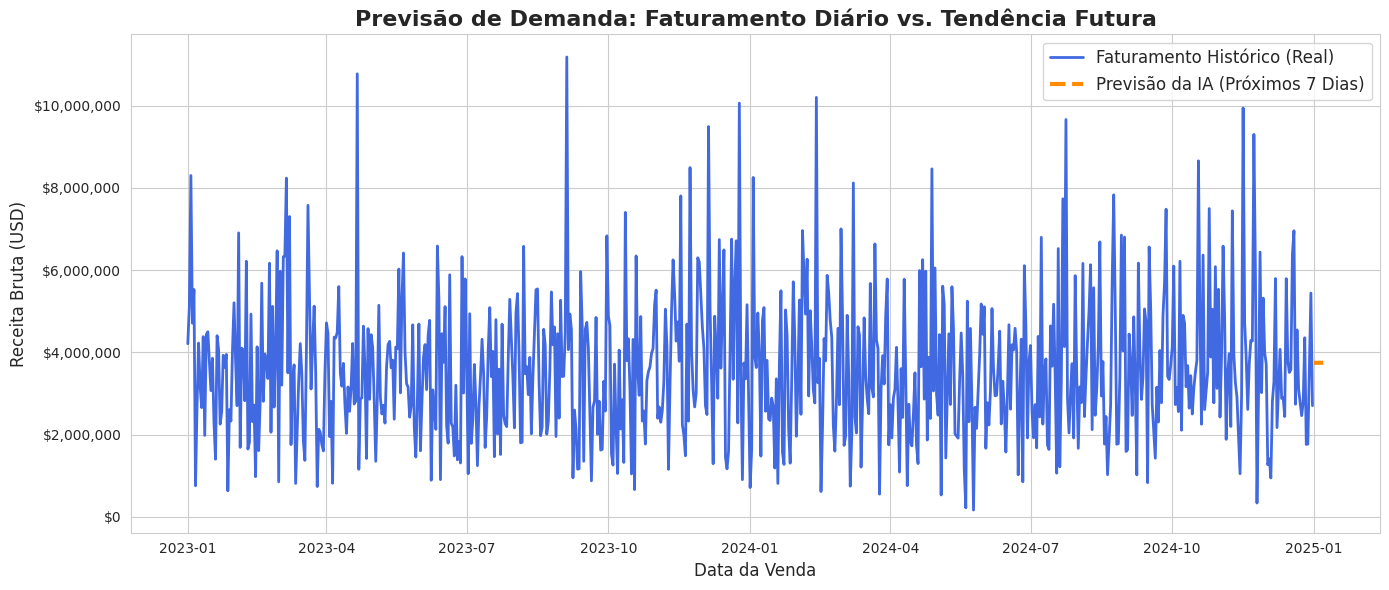

In [0]:
# Machine Learning - Previsão de Demanda (Forecasting)
# Prever o faturamento (Receita Bruta) dos próximos 7 dias.
# Regressão Linear (scikit-learn) aplicada a Séries Temporais.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings("ignore")

print("1. Preparando os dados históricos de vendas...")
# Tabela Ouro
df = spark.table("lh_nautical.lh_nautical_db.gld_lucro_detalhado").toPandas()

# Garante que a data é do tipo correto e agrupamos o faturamento por dia
df['sale_date'] = pd.to_datetime(df['sale_date'])
df_diario = df.groupby('sale_date')['gross_revenue'].sum().reset_index()
df_diario = df_diario.sort_values('sale_date')

# Cria uma coluna de "Dias Passados"
df_diario['dias_passados'] = (df_diario['sale_date'] - df_diario['sale_date'].min()).dt.days

print("2. Treinando a Inteligência Artificial (Regressão Linear)...")
# Separa o X (Tempo) e o Y (Dinheiro)
X_treino = df_diario[['dias_passados']]
y_treino = df_diario['gross_revenue']

# O Algoritmo aprende a tendência de vendas
modelo_ia = LinearRegression()
modelo_ia.fit(X_treino, y_treino)

print("3. Prevendo o futuro: A campanha da semana que vem!")
# Cria os próximos 7 dias no futuro
ultimo_dia_historico = df_diario['dias_passados'].max()
proximos_7_dias_numeros = np.array([ultimo_dia_historico + i for i in range(1, 8)]).reshape(-1, 1)

# A IA faz a previsão de quanto vamos faturar nesses dias
previsao_faturamento = modelo_ia.predict(proximos_7_dias_numeros)

# Traduz os números de volta para Datas do Calendário
ultima_data = df_diario['sale_date'].max()
datas_futuras = [ultima_data + pd.Timedelta(days=i) for i in range(1, 8)]

df_previsao = pd.DataFrame({
    'Data_Prevista': datas_futuras,
    'Faturamento_Estimado_USD': previsao_faturamento
})

print("\n--- RESULTADO DA PREVISÃO PARA A DIRETORIA ---")
display(df_previsao.round(2))

# ==============================================================================
# Passado vs. Futuro
# ==============================================================================
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

# Plotando o histórico real (Linha Azul)
plt.plot(df_diario['sale_date'], df_diario['gross_revenue'], label='Faturamento Histórico (Real)', color='royalblue', linewidth=2)

# Plotando a previsão da IA (Linha Laranja Tracejada)
plt.plot(df_previsao['Data_Prevista'], df_previsao['Faturamento_Estimado_USD'], label='Previsão da IA (Próximos 7 Dias)', color='darkorange', linewidth=3, linestyle='--')

plt.title('Previsão de Demanda: Faturamento Diário vs. Tendência Futura', fontsize=16, fontweight='bold')
plt.xlabel('Data da Venda', fontsize=12)
plt.ylabel('Receita Bruta (USD)', fontsize=12)
plt.legend(fontsize=12)

# Formatando em Dólares
formatter = ticker.StrMethodFormatter('${x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()